# 03 — Model Training and Evaluation

This notebook trains predictive models for match outcomes and goal counts and presents the most relevant evaluation plots for the World Cup 2026 project.

## Project Setup

The processed modelling dataset and output directories are initialized.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from pandas.api.types import is_numeric_dtype
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.dummy import DummyClassifier, DummyRegressor

PROJECT_DIR = Path("..").resolve()
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
OUTPUT_DIR = PROJECT_DIR / "output"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"
PREDICTIONS_DIR = OUTPUT_DIR / "predictions"

for directory in [TABLES_DIR, FIGURES_DIR, MODELS_DIR, PREDICTIONS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project folder:", PROJECT_DIR)
print("Processed data folder:", PROCESSED_DIR)


Project folder: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026
Processed data folder: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\data\processed


## Load Model Dataset

The feature-engineered dataset is loaded for modelling.

In [2]:
model_dataset = pd.read_csv(PROCESSED_DIR / "model_dataset.csv")
model_dataset["date"] = pd.to_datetime(model_dataset["date"], errors="coerce")

print("Model dataset shape:", model_dataset.shape)
display(model_dataset.head())


Model dataset shape: (8000, 45)


,team_a,team_b,date,tournament,neutral,team_a_matches_last5,team_b_matches_last5,team_a_win_rate_last5,team_b_win_rate_last5,team_a_draw_rate_last5,...,avg_goal_diff_diff_last10,h2h_matches,team_a_h2h_win_rate,team_b_h2h_win_rate,h2h_draw_rate,team_a_h2h_avg_goals,team_b_h2h_avg_goals,team_a_goals,team_b_goals,result
0,Algeria,Cabo Verde,2007-03-24,African Nations Cup qualifier,False,5,5,0.4,0.2,0.2,...,0.7,2,0.50,0.00,0.5,1.00,0.000000,2,0,team_a_win
1,Portugal,Belgium,2007-03-24,European Championship qual,False,5,5,0.6,0.4,0.2,...,0.0,1,0.00,0.00,1.0,1.00,1.000000,4,0,team_a_win
2,Norway,Bosnia and Herzegovina,2007-03-24,European Championship qual,False,5,5,0.4,0.2,0.2,...,0.6,2,0.50,0.50,0.0,1.00,0.500000,1,2,team_b_win
3,Netherlands,Romania,2007-03-24,European Championship qual,False,5,5,0.6,0.2,0.4,...,1.3,3,1.00,0.00,0.0,2.00,0.333333,0,0,draw
4,Czechia,Germany,2007-03-24,European Championship qual,False,5,5,0.8,0.8,0.0,...,-1.9,4,0.25,0.75,0.0,1.25,2.000000,1,2,team_b_win


## Dataset Overview

The distribution of classes, tournaments, matches over time, and goals is explored before training.

In [3]:
print("Result distribution:")
display(model_dataset["result"].value_counts().to_frame("count"))

print("Goal summary:")
display(model_dataset[["team_a_goals", "team_b_goals"]].describe())

print("Date range:")
print(model_dataset["date"].min(), "to", model_dataset["date"].max())


Result distribution:


,count
result,
team_a_win,4609
draw,1869
team_b_win,1522


Goal summary:


,team_a_goals,team_b_goals
count,8000.000000,8000.000000
mean,1.775500,0.892875
std,1.584744,1.117388
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,3.000000,1.000000
max,15.000000,10.000000


Date range:
2007-03-24 00:00:00 to 2026-06-10 00:00:00


## Exploratory Visualizations

These plots summarize the modelling dataset and provide presentation-ready context.

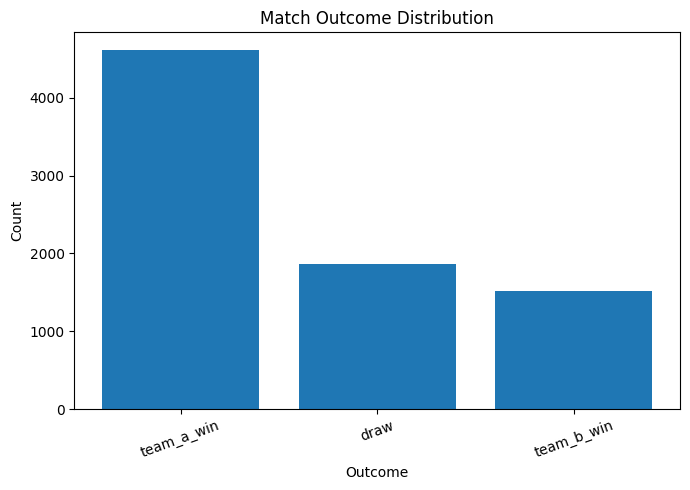

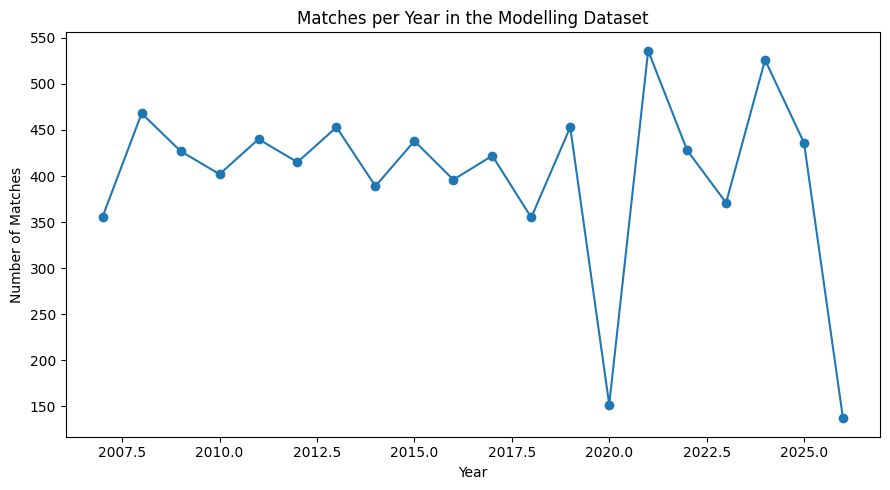

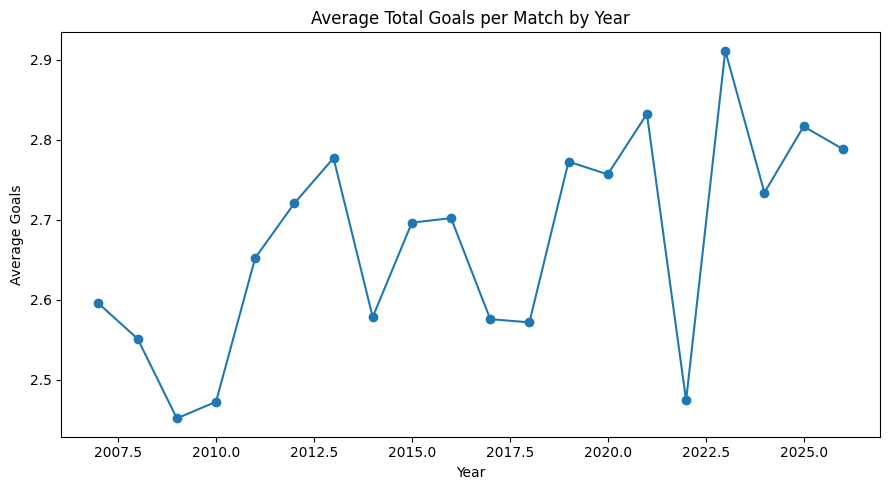

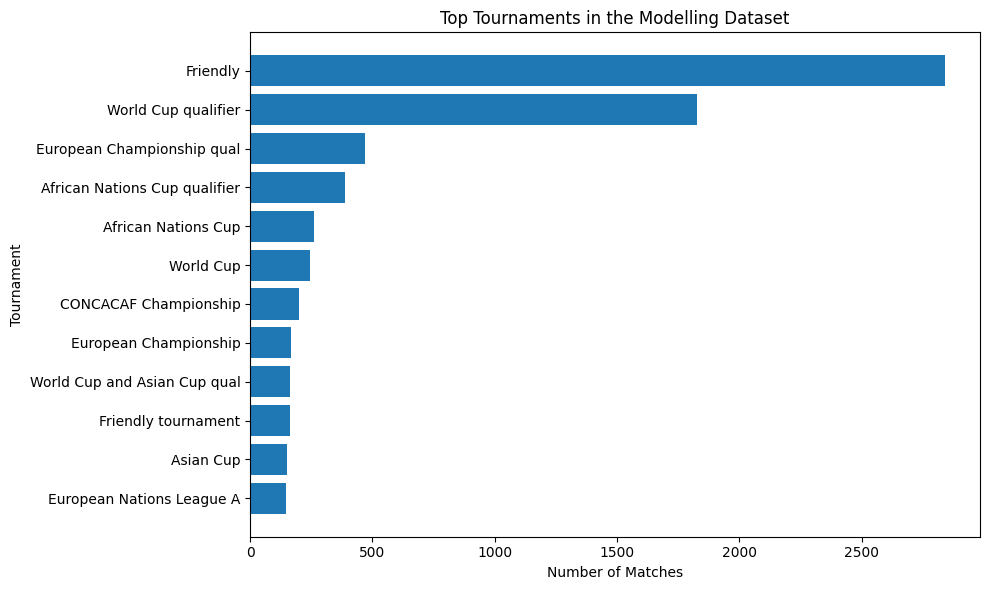

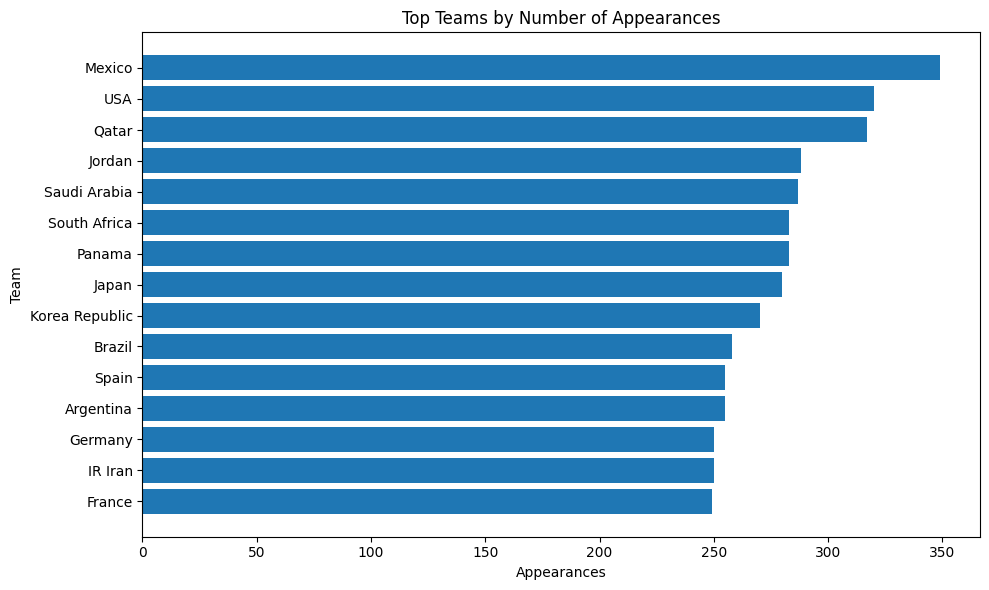

In [4]:
# 1) Match outcome distribution
result_counts = model_dataset["result"].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(result_counts.index, result_counts.values)
ax.set_title("Match Outcome Distribution")
ax.set_xlabel("Outcome")
ax.set_ylabel("Count")
plt.xticks(rotation=20)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_result_distribution.png", dpi=150)
plt.show()

# 2) Matches per year
matches_per_year = model_dataset.groupby(model_dataset["date"].dt.year).size()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(matches_per_year.index, matches_per_year.values, marker="o")
ax.set_title("Matches per Year in the Modelling Dataset")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Matches")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_matches_per_year.png", dpi=150)
plt.show()

# 3) Average total goals per year
temp_goals = model_dataset.copy()
temp_goals["total_goals"] = temp_goals["team_a_goals"] + temp_goals["team_b_goals"]
avg_goals_per_year = temp_goals.groupby(temp_goals["date"].dt.year)["total_goals"].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(avg_goals_per_year.index, avg_goals_per_year.values, marker="o")
ax.set_title("Average Total Goals per Match by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Average Goals")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_avg_goals_per_year.png", dpi=150)
plt.show()

# 4) Top tournaments
top_tournaments = model_dataset["tournament"].value_counts().head(12)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_tournaments.index[::-1], top_tournaments.values[::-1])
ax.set_title("Top Tournaments in the Modelling Dataset")
ax.set_xlabel("Number of Matches")
ax.set_ylabel("Tournament")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_top_tournaments.png", dpi=150)
plt.show()

# 5) Top teams by number of appearances
all_teams = pd.concat([model_dataset["team_a"], model_dataset["team_b"]], axis=0)
top_teams = all_teams.value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_teams.index[::-1], top_teams.values[::-1])
ax.set_title("Top Teams by Number of Appearances")
ax.set_xlabel("Appearances")
ax.set_ylabel("Team")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_top_teams.png", dpi=150)
plt.show()


## Feature Selection

The target variables and input features are separated.

In [5]:
target_classification = "result"
target_goals_a = "team_a_goals"
target_goals_b = "team_b_goals"

identifier_columns = ["team_a", "team_b", "date"]
target_columns = [target_classification, target_goals_a, target_goals_b]

feature_columns = [
    col for col in model_dataset.columns
    if col not in identifier_columns + target_columns
]

X = model_dataset[feature_columns].copy()
y_result = model_dataset[target_classification].copy()
y_goals_a = model_dataset[target_goals_a].copy()
y_goals_b = model_dataset[target_goals_b].copy()

numeric_features = [
    col for col in X.columns
    if is_numeric_dtype(X[col])
]

categorical_features = [
    col for col in X.columns
    if col not in numeric_features
]

print("Number of features:", len(feature_columns))
print("Categorical features:", categorical_features)
print("Number of numeric features:", len(numeric_features))

print("\nNumeric feature examples:")
print(numeric_features[:10])

print("\nCategorical feature examples:")
print(categorical_features[:10])


Number of features: 39
Categorical features: ['tournament']
Number of numeric features: 38

Numeric feature examples:
['neutral', 'team_a_matches_last5', 'team_b_matches_last5', 'team_a_win_rate_last5', 'team_b_win_rate_last5', 'team_a_draw_rate_last5', 'team_b_draw_rate_last5', 'team_a_loss_rate_last5', 'team_b_loss_rate_last5', 'team_a_points_per_match_last5']

Categorical feature examples:
['tournament']


## Chronological Train-Test Split

A time-based split is used so that earlier matches are used for training and later matches are used for evaluation.

In [6]:
model_dataset_sorted = model_dataset.sort_values("date").reset_index(drop=True)

split_index = int(len(model_dataset_sorted) * 0.8)

train_data = model_dataset_sorted.iloc[:split_index].copy()
test_data = model_dataset_sorted.iloc[split_index:].copy()

X_train = train_data[feature_columns].copy()
X_test = test_data[feature_columns].copy()

y_train_result = train_data[target_classification].copy()
y_test_result = test_data[target_classification].copy()

y_train_goals_a = train_data[target_goals_a].copy()
y_test_goals_a = test_data[target_goals_a].copy()

y_train_goals_b = train_data[target_goals_b].copy()
y_test_goals_b = test_data[target_goals_b].copy()

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)
print("Train date range:", train_data["date"].min(), "to", train_data["date"].max())
print("Test date range:", test_data["date"].min(), "to", test_data["date"].max())


Train shape: (6400, 45)
Test shape: (1600, 45)
Train date range: 2007-03-24 00:00:00 to 2022-09-26 00:00:00
Test date range: 2022-09-27 00:00:00 to 2026-06-10 00:00:00


## Preprocessing Pipeline

Numeric features are standardized and categorical features are one-hot encoded.

In [7]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

print("Preprocessing pipeline created.")


Preprocessing pipeline created.


## Classification Models

A baseline model, Logistic Regression, and Random Forest are trained for match outcome prediction.

In [8]:
baseline_classifier = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyClassifier(strategy="most_frequent"))
    ]
)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

rf_classifier = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

classification_models = {
    "Dummy Majority Baseline": baseline_classifier,
    "Logistic Regression": logistic_model,
    "Random Forest Classifier": rf_classifier,
}

classification_results = []

for name, model in classification_models.items():
    model.fit(X_train, y_train_result)
    pred = model.predict(X_test)

    classification_results.append({
        "model": name,
        "accuracy": accuracy_score(y_test_result, pred),
        "weighted_f1": f1_score(y_test_result, pred, average="weighted")
    })

classification_metrics = pd.DataFrame(classification_results).sort_values(
    "weighted_f1", ascending=False
).reset_index(drop=True)

display(classification_metrics)
classification_metrics.to_csv(TABLES_DIR / "classification_model_metrics.csv", index=False)
print("Saved:", TABLES_DIR / "classification_model_metrics.csv")


,model,accuracy,weighted_f1
0,Logistic Regression,0.624375,0.621858
1,Random Forest Classifier,0.640625,0.614340
2,Dummy Majority Baseline,0.581875,0.428072


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\tables\classification_model_metrics.csv


## Classification Performance Plot

Accuracy and weighted F1-score are compared across models.

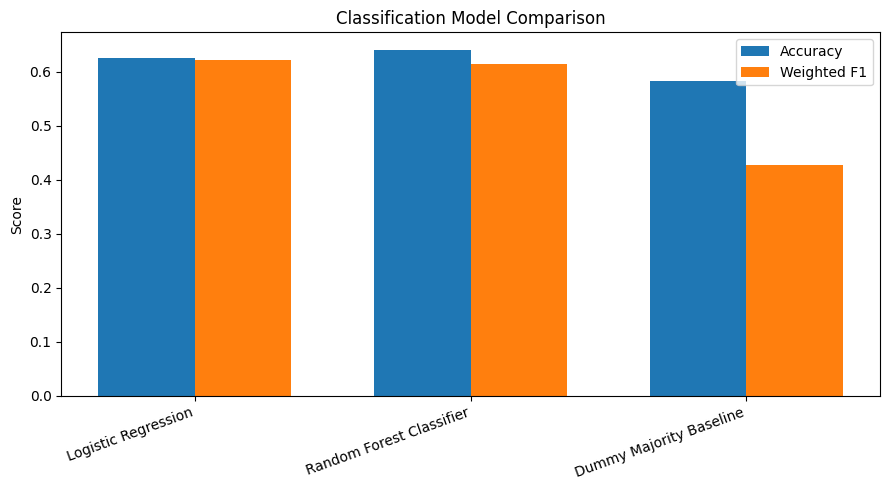

In [9]:
plot_df = classification_metrics.set_index("model")

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(plot_df.index))
width = 0.35

ax.bar(x - width/2, plot_df["accuracy"], width, label="Accuracy")
ax.bar(x + width/2, plot_df["weighted_f1"], width, label="Weighted F1")

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=20, ha="right")
ax.set_ylabel("Score")
ax.set_title("Classification Model Comparison")
ax.legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "classification_model_comparison.png", dpi=150)
plt.show()


## Best Classification Model

The best outcome classifier is selected based on weighted F1-score.

In [10]:
best_classifier_name = classification_metrics.iloc[0]["model"]
best_classifier = classification_models[best_classifier_name]
best_classifier.fit(X_train, y_train_result)
best_pred = best_classifier.predict(X_test)

print("Selected classification model:", best_classifier_name)
print(classification_report(y_test_result, best_pred))


Selected classification model: Logistic Regression
              precision    recall  f1-score   support

        draw       0.39      0.32      0.35       382
  team_a_win       0.77      0.72      0.74       931
  team_b_win       0.50      0.74      0.60       287

    accuracy                           0.62      1600
   macro avg       0.55      0.59      0.56      1600
weighted avg       0.63      0.62      0.62      1600



## Confusion Matrix

The confusion matrix shows the structure of classification errors for the best outcome model.

,draw,team_a_win,team_b_win
draw,121,158,103
team_a_win,160,667,104
team_b_win,33,43,211


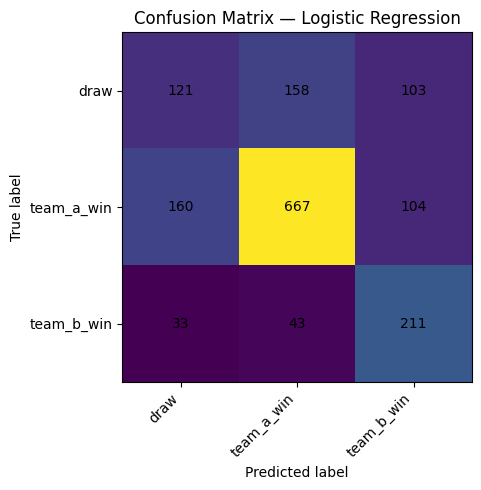

In [11]:
labels = sorted(y_test_result.unique())
cm = confusion_matrix(y_test_result, best_pred, labels=labels)

cm_df = pd.DataFrame(cm, index=labels, columns=labels)
display(cm_df)
cm_df.to_csv(TABLES_DIR / "classification_confusion_matrix.csv")

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(f"Confusion Matrix — {best_classifier_name}")

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "classification_confusion_matrix.png", dpi=150)
plt.show()


## Feature Importance

The importance of engineered features is visualized for the Random Forest classifier.

,feature,importance
0,numeric__neutral,0.085934
31,numeric__avg_goal_diff_diff_last10,0.073620
28,numeric__points_per_match_diff_last10,0.052615
30,numeric__avg_goals_conceded_diff_last10,0.047082
29,numeric__avg_goals_scored_diff_last10,0.045004
24,numeric__team_b_avg_goal_diff_last10,0.042144
37,numeric__team_b_h2h_avg_goals,0.040590
23,numeric__team_a_avg_goal_diff_last10,0.040560
27,numeric__win_rate_diff_last10,0.033936
33,numeric__team_a_h2h_win_rate,0.032557


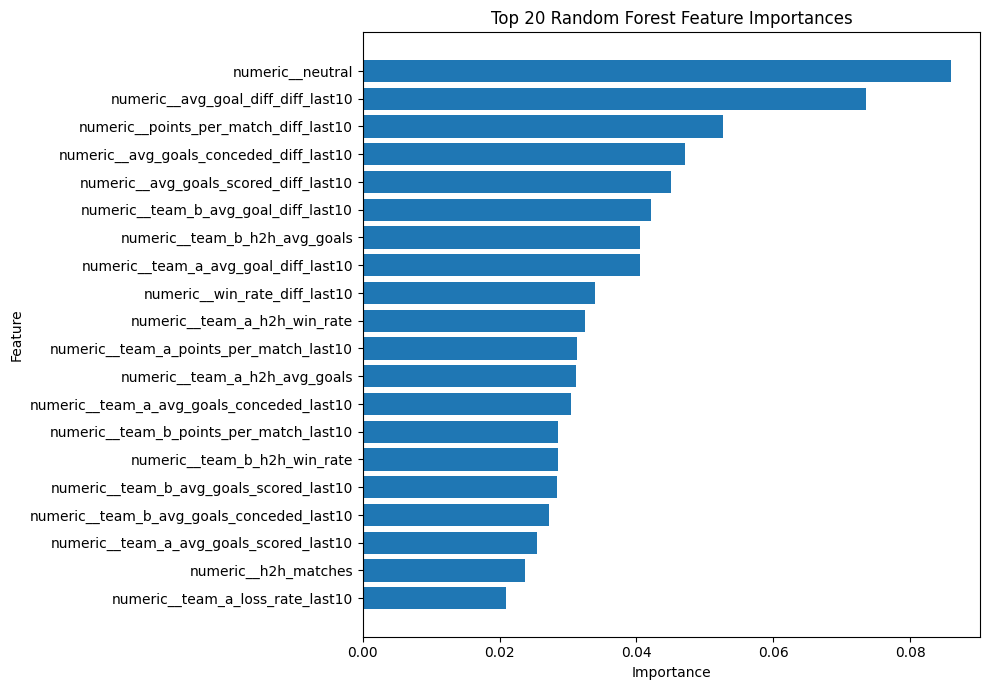

In [12]:
rf_classifier.fit(X_train, y_train_result)

rf_preprocessor = rf_classifier.named_steps["preprocessor"]
rf_model = rf_classifier.named_steps["model"]

feature_names = rf_preprocessor.get_feature_names_out()
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(importance_df.head(20))
importance_df.to_csv(TABLES_DIR / "rf_feature_importance.csv", index=False)

top_importance = importance_df.head(20).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_importance["feature"], top_importance["importance"])
ax.set_title("Top 20 Random Forest Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "rf_feature_importance_top20.png", dpi=150)
plt.show()


## Goal Regression Models

Baseline, Ridge Regression, and Random Forest models are trained for team goal prediction.

In [13]:
goal_models = {
    "Dummy Mean Baseline": (
        Pipeline([("preprocessor", preprocessor), ("model", DummyRegressor(strategy="mean"))]),
        Pipeline([("preprocessor", preprocessor), ("model", DummyRegressor(strategy="mean"))]),
    ),
    "Ridge Regression": (
        Pipeline([("preprocessor", preprocessor), ("model", Ridge(alpha=1.0))]),
        Pipeline([("preprocessor", preprocessor), ("model", Ridge(alpha=1.0))]),
    ),
    "Random Forest Regressor": (
        Pipeline([("preprocessor", preprocessor), ("model", RandomForestRegressor(
            n_estimators=300, max_depth=12, min_samples_leaf=5, random_state=42, n_jobs=-1
        ))]),
        Pipeline([("preprocessor", preprocessor), ("model", RandomForestRegressor(
            n_estimators=300, max_depth=12, min_samples_leaf=5, random_state=42, n_jobs=-1
        ))]),
    ),
}

def regression_metrics(y_true_a, pred_a, y_true_b, pred_b, model_name):
    mae_a = mean_absolute_error(y_true_a, pred_a)
    mae_b = mean_absolute_error(y_true_b, pred_b)
    rmse_a = np.sqrt(mean_squared_error(y_true_a, pred_a))
    rmse_b = np.sqrt(mean_squared_error(y_true_b, pred_b))
    r2_a = r2_score(y_true_a, pred_a)
    r2_b = r2_score(y_true_b, pred_b)

    return {
        "model": model_name,
        "team_a_mae": mae_a,
        "team_b_mae": mae_b,
        "mean_mae": (mae_a + mae_b) / 2,
        "team_a_rmse": rmse_a,
        "team_b_rmse": rmse_b,
        "mean_rmse": (rmse_a + rmse_b) / 2,
        "team_a_r2": r2_a,
        "team_b_r2": r2_b,
        "mean_r2": (r2_a + r2_b) / 2,
    }

regression_rows = []
regression_predictions = {}

for name, (model_a, model_b) in goal_models.items():
    model_a.fit(X_train, y_train_goals_a)
    model_b.fit(X_train, y_train_goals_b)

    pred_a = model_a.predict(X_test)
    pred_b = model_b.predict(X_test)

    regression_rows.append(regression_metrics(
        y_test_goals_a, pred_a, y_test_goals_b, pred_b, name
    ))
    regression_predictions[name] = (model_a, model_b, pred_a, pred_b)

regression_metrics_df = pd.DataFrame(regression_rows).sort_values(
    "mean_mae", ascending=True
).reset_index(drop=True)

display(regression_metrics_df)
regression_metrics_df.to_csv(TABLES_DIR / "goal_regression_model_metrics.csv", index=False)
print("Saved:", TABLES_DIR / "goal_regression_model_metrics.csv")


,model,team_a_mae,team_b_mae,mean_mae,team_a_rmse,team_b_rmse,mean_rmse,team_a_r2,team_b_r2,mean_r2
0,Ridge Regression,1.088932,0.740156,0.914544,1.420728,0.994301,1.207515,0.247671,0.234034,0.240852
1,Random Forest Regressor,1.085822,0.748072,0.916947,1.417086,0.986292,1.201689,0.251523,0.246323,0.248923
2,Dummy Mean Baseline,1.239940,0.831278,1.035609,1.642398,1.136226,1.389312,-0.005409,-0.000237,-0.002823


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\tables\goal_regression_model_metrics.csv


## Goal Regression Performance Plot

Goal prediction models are compared with MAE and RMSE.

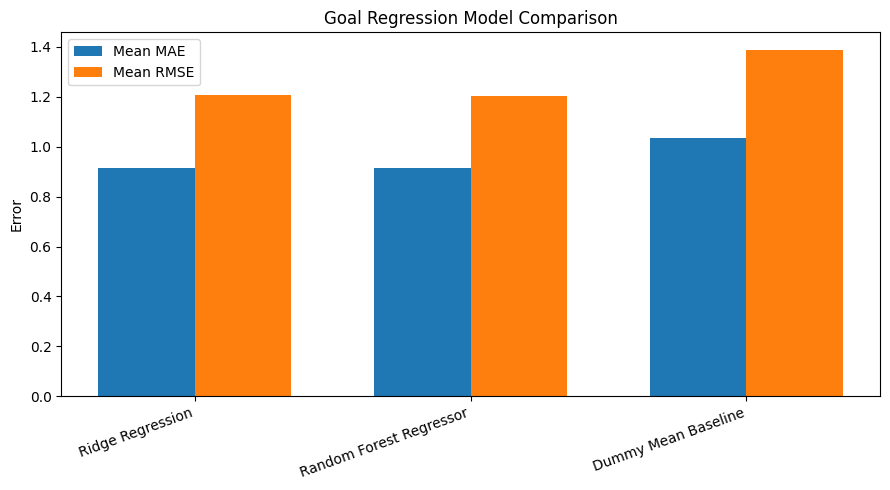

In [14]:
plot_df = regression_metrics_df.set_index("model")

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(plot_df.index))
width = 0.35

ax.bar(x - width/2, plot_df["mean_mae"], width, label="Mean MAE")
ax.bar(x + width/2, plot_df["mean_rmse"], width, label="Mean RMSE")

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=20, ha="right")
ax.set_ylabel("Error")
ax.set_title("Goal Regression Model Comparison")
ax.legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "goal_regression_model_comparison.png", dpi=150)
plt.show()


## Best Goal Regression Model

The goal model with the lowest mean MAE is selected.

In [15]:
best_regression_name = regression_metrics_df.iloc[0]["model"]
best_goals_a_model, best_goals_b_model, best_goals_a_pred, best_goals_b_pred = regression_predictions[best_regression_name]

print("Selected goal regression model:", best_regression_name)


Selected goal regression model: Ridge Regression


## Actual vs Predicted Goals

Predicted goals are compared against actual goals for both teams.

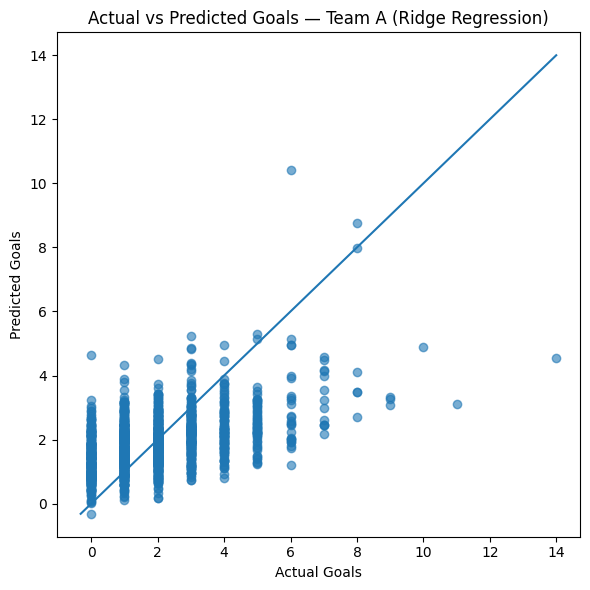

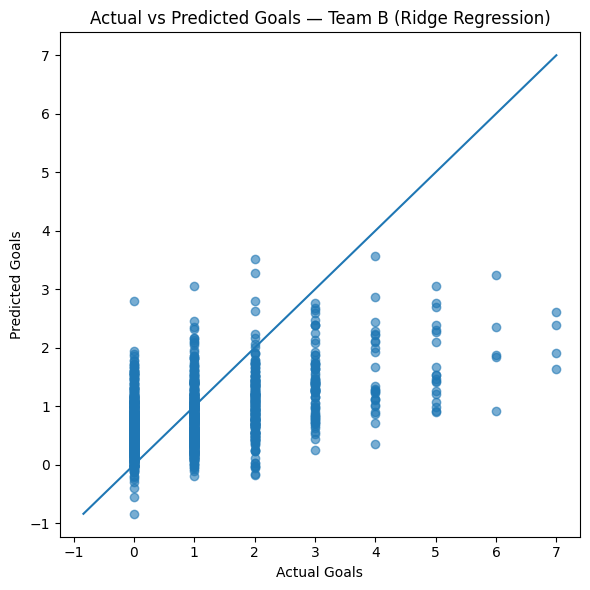

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_goals_a, best_goals_a_pred, alpha=0.6)
min_val = min(y_test_goals_a.min(), best_goals_a_pred.min())
max_val = max(y_test_goals_a.max(), best_goals_a_pred.max())
ax.plot([min_val, max_val], [min_val, max_val])
ax.set_title(f"Actual vs Predicted Goals — Team A ({best_regression_name})")
ax.set_xlabel("Actual Goals")
ax.set_ylabel("Predicted Goals")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "actual_vs_predicted_goals_team_a.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_goals_b, best_goals_b_pred, alpha=0.6)
min_val = min(y_test_goals_b.min(), best_goals_b_pred.min())
max_val = max(y_test_goals_b.max(), best_goals_b_pred.max())
ax.plot([min_val, max_val], [min_val, max_val])
ax.set_title(f"Actual vs Predicted Goals — Team B ({best_regression_name})")
ax.set_xlabel("Actual Goals")
ax.set_ylabel("Predicted Goals")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "actual_vs_predicted_goals_team_b.png", dpi=150)
plt.show()


## Residual Analysis

Residual distributions summarize prediction errors for both goal models.

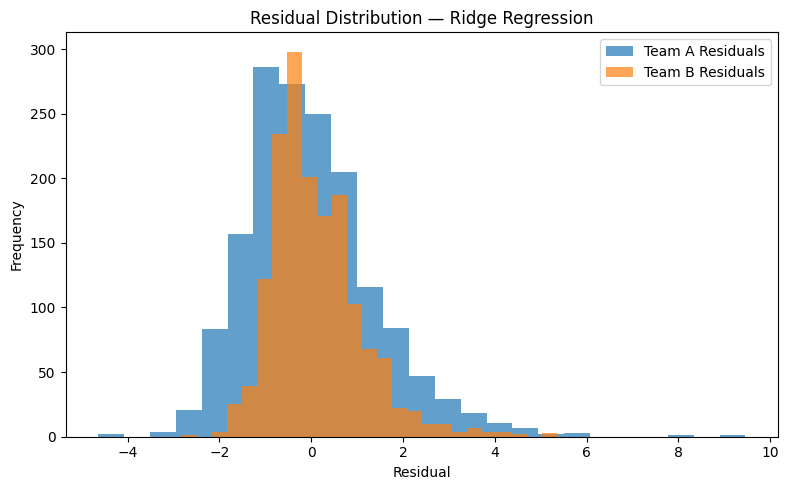

In [17]:
residuals_a = y_test_goals_a - best_goals_a_pred
residuals_b = y_test_goals_b - best_goals_b_pred

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(residuals_a, bins=25, alpha=0.7, label="Team A Residuals")
ax.hist(residuals_b, bins=25, alpha=0.7, label="Team B Residuals")
ax.set_title(f"Residual Distribution — {best_regression_name}")
ax.set_xlabel("Residual")
ax.set_ylabel("Frequency")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "goal_prediction_residuals.png", dpi=150)
plt.show()


## Prediction Export

Predictions on the test set are exported for review.

In [18]:
test_predictions = test_data[["date", "team_a", "team_b", "tournament", "team_a_goals", "team_b_goals", "result"]].copy()
test_predictions["predicted_result"] = best_pred
test_predictions["predicted_team_a_goals"] = best_goals_a_pred
test_predictions["predicted_team_b_goals"] = best_goals_b_pred
test_predictions["predicted_score"] = (
    test_predictions["predicted_team_a_goals"].round(1).astype(str)
    + " - "
    + test_predictions["predicted_team_b_goals"].round(1).astype(str)
)

display(test_predictions.head(20))
test_predictions.to_csv(PREDICTIONS_DIR / "test_predictions.csv", index=False)
print("Saved:", PREDICTIONS_DIR / "test_predictions.csv")


,date,team_a,team_b,tournament,team_a_goals,team_b_goals,result,predicted_result,predicted_team_a_goals,predicted_team_b_goals,predicted_score
6400,2022-09-27,Indonesia,Curaçao,Friendly,2,1,team_a_win,team_b_win,1.635726,1.579558,1.6 - 1.6
6401,2022-09-27,IR Iran,Senegal,Friendly,1,1,draw,team_a_win,1.652654,0.695017,1.7 - 0.7
6402,2022-09-27,Brazil,Tunisia,Friendly,5,1,team_a_win,team_a_win,1.956091,0.465016,2.0 - 0.5
6403,2022-09-27,Algeria,Nigeria,Friendly,2,1,team_a_win,draw,1.591443,0.777442,1.6 - 0.8
6404,2022-09-27,South Africa,Botswana,Friendly,1,0,team_a_win,team_a_win,1.970381,0.454890,2.0 - 0.5
6405,2022-09-27,Egypt,Liberia,Friendly tournament,3,0,team_a_win,team_a_win,2.380896,0.324433,2.4 - 0.3
6406,2022-09-27,Costa Rica,Uzbekistan,Friendly,2,1,team_a_win,draw,1.325779,0.840191,1.3 - 0.8
6407,2022-09-27,Bahrain,Panama,Friendly,0,2,team_b_win,team_a_win,2.249792,0.788822,2.2 - 0.8
6408,2022-09-27,Saudi Arabia,USA,Friendly,0,0,draw,draw,0.985487,0.926095,1.0 - 0.9
6409,2022-09-27,Korea Republic,Cameroon,Friendly,1,0,team_a_win,draw,1.605092,0.834239,1.6 - 0.8


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\predictions\test_predictions.csv


## Save Trained Models

The selected models are saved for World Cup 2026 fixture prediction.

In [19]:
joblib.dump(best_classifier, MODELS_DIR / "best_match_result_model.joblib")
joblib.dump(best_goals_a_model, MODELS_DIR / "best_team_a_goals_model.joblib")
joblib.dump(best_goals_b_model, MODELS_DIR / "best_team_b_goals_model.joblib")

model_selection_summary = pd.DataFrame([
    {"task": "match_result_classification", "selected_model": best_classifier_name},
    {"task": "team_a_goal_regression", "selected_model": best_regression_name},
    {"task": "team_b_goal_regression", "selected_model": best_regression_name},
])

display(model_selection_summary)
model_selection_summary.to_csv(TABLES_DIR / "model_selection_summary.csv", index=False)

print("Saved:", MODELS_DIR / "best_match_result_model.joblib")
print("Saved:", MODELS_DIR / "best_team_a_goals_model.joblib")
print("Saved:", MODELS_DIR / "best_team_b_goals_model.joblib")
print("Saved:", TABLES_DIR / "model_selection_summary.csv")


,task,selected_model
0,match_result_classification,Logistic Regression
1,team_a_goal_regression,Ridge Regression
2,team_b_goal_regression,Ridge Regression


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\models\best_match_result_model.joblib
Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\models\best_team_a_goals_model.joblib
Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\models\best_team_b_goals_model.joblib
Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\tables\model_selection_summary.csv


## Final Output Overview

All model metrics, figures, predictions, and trained models are available for the next project step.

In [20]:
print("Tables:")
print(" - output/tables/classification_model_metrics.csv")
print(" - output/tables/classification_confusion_matrix.csv")
print(" - output/tables/goal_regression_model_metrics.csv")
print(" - output/tables/model_selection_summary.csv")
print(" - output/tables/rf_feature_importance.csv")

print("\nFigures:")
print(" - output/figures/eda_result_distribution.png")
print(" - output/figures/eda_matches_per_year.png")
print(" - output/figures/eda_avg_goals_per_year.png")
print(" - output/figures/eda_top_tournaments.png")
print(" - output/figures/eda_top_teams.png")
print(" - output/figures/classification_model_comparison.png")
print(" - output/figures/classification_confusion_matrix.png")
print(" - output/figures/rf_feature_importance_top20.png")
print(" - output/figures/goal_regression_model_comparison.png")
print(" - output/figures/actual_vs_predicted_goals_team_a.png")
print(" - output/figures/actual_vs_predicted_goals_team_b.png")
print(" - output/figures/goal_prediction_residuals.png")

print("\nPredictions:")
print(" - output/predictions/test_predictions.csv")

print("\nModels:")
print(" - output/models/best_match_result_model.joblib")
print(" - output/models/best_team_a_goals_model.joblib")
print(" - output/models/best_team_b_goals_model.joblib")

print("\nModel training and evaluation completed.")


Tables:
 - output/tables/classification_model_metrics.csv
 - output/tables/classification_confusion_matrix.csv
 - output/tables/goal_regression_model_metrics.csv
 - output/tables/model_selection_summary.csv
 - output/tables/rf_feature_importance.csv

Figures:
 - output/figures/eda_result_distribution.png
 - output/figures/eda_matches_per_year.png
 - output/figures/eda_avg_goals_per_year.png
 - output/figures/eda_top_tournaments.png
 - output/figures/eda_top_teams.png
 - output/figures/classification_model_comparison.png
 - output/figures/classification_confusion_matrix.png
 - output/figures/rf_feature_importance_top20.png
 - output/figures/goal_regression_model_comparison.png
 - output/figures/actual_vs_predicted_goals_team_a.png
 - output/figures/actual_vs_predicted_goals_team_b.png
 - output/figures/goal_prediction_residuals.png

Predictions:
 - output/predictions/test_predictions.csv

Models:
 - output/models/best_match_result_model.joblib
 - output/models/best_team_a_goals_model.jo